# Premiers Tests pour le PFE

## Visualisation de l'ontologie

In [6]:
import networkx as nx
import matplotlib.pyplot as plt
from rdflib import Graph, Literal

# Fonction de visualisation
def visualiser_ontologie(g, titre="Ontologie RDF"):
    G = nx.Graph()
    for s, p, o in g:
        subj = str(s).split("/")[-1]
        if isinstance(o, Literal):
            obj = str(o)
        else:
            obj = str(o).split("/")[-1]
        G.add_edge(subj, obj, label=str(p).split("/")[-1])

    plt.figure(figsize=(8,6))
    pos = nx.spring_layout(G, seed=42)

    nx.draw_networkx_nodes(G, pos, node_size=2000, node_color="lightblue")
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold")
    nx.draw_networkx_edges(G, pos, width=1.5, edge_color="gray")

    edge_labels = nx.get_edge_attributes(G, 'label')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    plt.title(titre, fontsize=12)
    plt.axis("off")
    plt.show()

## Mini-ontologie

Ontologie de base :
http://example.org/Aspirin http://www.w3.org/2000/01/rdf-schema#label Aspirin
http://example.org/Paracetamol http://www.w3.org/2000/01/rdf-schema#label Paracetamol
http://example.org/Ibuprofen http://www.w3.org/2000/01/rdf-schema#label Ibuprofen


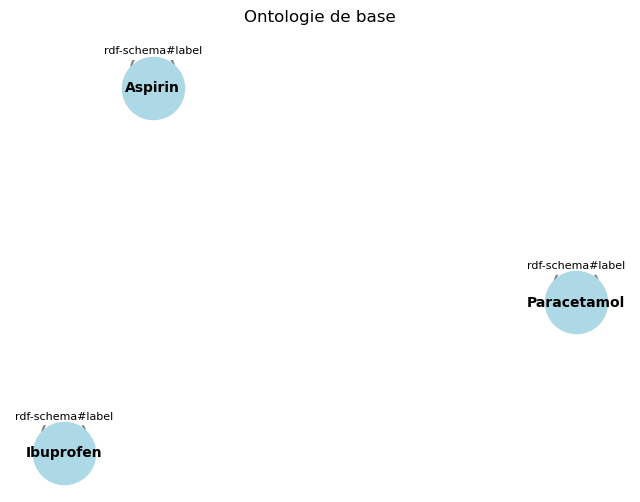

In [ ]:
from rdflib import Graph, URIRef, Literal, Namespace, RDFS
import pandas as pd

# Namespace
EX = Namespace("http://example.org/")

# Graphe RDF
g = Graph()

# Molécules de départ
molecules = ["Aspirin", "Paracetamol", "Ibuprofen"]

for mol in molecules:
    g.add((URIRef(EX[mol]), RDFS.label, Literal(mol)))

print("Ontologie de base :")
for s, p, o in g:
    print(s, p, o)

visualiser_ontologie(g, "Ontologie de base")

## Ajouter des synonymes


Ontologie enrichie avec synonymes externes :
http://example.org/Aspirin http://www.w3.org/2000/01/rdf-schema#label Aspirin
http://example.org/Aspirin http://www.w3.org/2000/01/rdf-schema#label ASA
http://example.org/Paracetamol http://www.w3.org/2000/01/rdf-schema#label Paracetamol
http://example.org/Ibuprofen http://www.w3.org/2000/01/rdf-schema#label Ibuprofen
http://example.org/Ibuprofen http://www.w3.org/2000/01/rdf-schema#label Advil
http://example.org/Aspirin http://www.w3.org/2000/01/rdf-schema#label Acetylsalicylic acid
http://example.org/Paracetamol http://www.w3.org/2000/01/rdf-schema#label Acetaminophen
http://example.org/Ibuprofen http://www.w3.org/2000/01/rdf-schema#label Nurofen


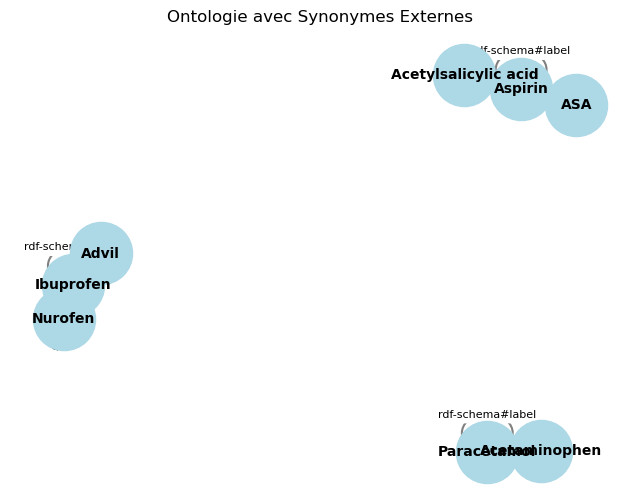

In [8]:
df = pd.read_csv("synonyms.csv")

for _, row in df.iterrows():
    mol = URIRef(EX[row["molecule"]])
    g.add((mol, RDFS.label, Literal(row["synonym"])))

print("\nOntologie enrichie avec synonymes externes :")
for s, p, o in g:
    print(s, p, o)

visualiser_ontologie(g, "Ontologie avec Synonymes Externes")

## Détection automatique de synonymes candidats (TF-IDF)

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Exemple de termes trouvés dans la littérature
unknown_terms = ["ASA", "Acetaminophen", "Advil", "Vitamin C"]

# On compare avec les labels connus de notre graphe
all_terms = list(set(df["synonym"].tolist() + molecules))
vectorizer = TfidfVectorizer().fit_transform(all_terms + unknown_terms)

similarities = cosine_similarity(vectorizer[-len(unknown_terms):], vectorizer[:-len(unknown_terms)])

print("\nCandidats synonymes détectés :")
for i, ut in enumerate(unknown_terms):
    best_idx = similarities[i].argmax()
    print(f"{ut} ≈ {all_terms[best_idx]} (score {similarities[i, best_idx]:.2f})")


Candidats synonymes détectés :
ASA ≈ ASA (score 1.00)
Acetaminophen ≈ Acetaminophen (score 1.00)
Advil ≈ Advil (score 1.00)
Vitamin C ≈ Nurofen (score 0.00)


## Enrichir automatiquement l’ontologie


Ontologie finale avec SKOS altLabel :
http://example.org/Aspirin http://www.w3.org/2000/01/rdf-schema#label Aspirin
http://example.org/Aspirin http://www.w3.org/2000/01/rdf-schema#label ASA
http://example.org/Acetaminophen http://www.w3.org/2004/02/skos/core#altLabel Acetaminophen
http://example.org/Paracetamol http://www.w3.org/2000/01/rdf-schema#label Paracetamol
http://example.org/Ibuprofen http://www.w3.org/2000/01/rdf-schema#label Ibuprofen
http://example.org/Ibuprofen http://www.w3.org/2000/01/rdf-schema#label Advil
http://example.org/ASA http://www.w3.org/2004/02/skos/core#altLabel ASA
http://example.org/Aspirin http://www.w3.org/2000/01/rdf-schema#label Acetylsalicylic acid
http://example.org/Paracetamol http://www.w3.org/2000/01/rdf-schema#label Acetaminophen
http://example.org/Advil http://www.w3.org/2004/02/skos/core#altLabel Advil
http://example.org/Ibuprofen http://www.w3.org/2000/01/rdf-schema#label Nurofen


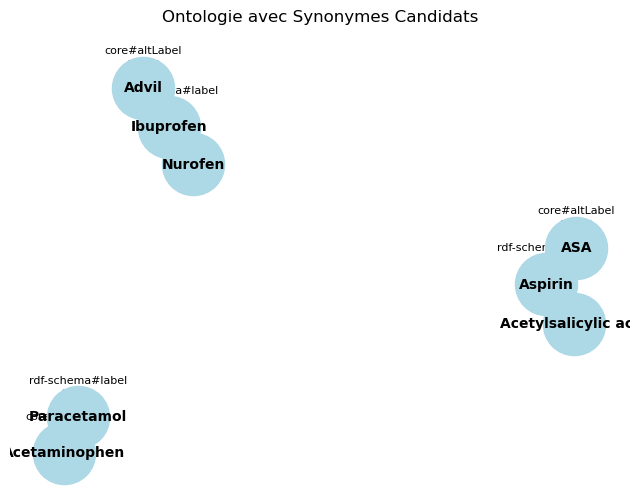

In [13]:
from rdflib.namespace import SKOS

for i, ut in enumerate(unknown_terms):
    best_idx = similarities[i].argmax()
    if similarities[i, best_idx] > 0.3:  # seuil arbitraire
        g.add((URIRef(EX[all_terms[best_idx]]), SKOS.altLabel, Literal(ut)))

print("\nOntologie finale avec SKOS altLabel :")
#for s, p, o in g.triples((None, SKOS.altLabel, None)):
    #print(s, p, o)

for s, p, o in g:
    print(s, p, o)

visualiser_ontologie(g, "Ontologie avec Synonymes Candidats")